<div style="display: flex; background-color: RGB(255,114,0);" >
<h1 style="margin: auto; padding: 30px; ">ANALYSE DU STOCK ET DES VENTES DU SITE BOTTLENECK</h1>
</div>

# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner code, texte et graphiques.

Cet outil est formidable pour plusieurs raisons:

+ Il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'une instruction, de la corriger si nécessaire.
+ Il permet aussi de rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ Il est possible d'ajouter des graphiques

Pour vous aider dans vos premiers pas à l'usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l'instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandé.

Et gardez à l'esprit qu'il n'y a pas de solution unique pour résoudre un problème et qu'il y a autant de résolutions de problèmes que de développeurs ;)...



<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.1 - Importation des librairies</h3>
</div>

In [277]:
#Importation des librairies Pandas, Seaborn et Matpotlib
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [278]:
#Importation de la librairie plotly express
import plotly.express as px

In [279]:
#Trouver dans Google l'instruction permettant d'afficher toutes les colonnes d'un dataframe
#Saisir dans Google les mots clés "display all columns dataframe Pandas" par exemple.
#Dans les résultats de la recherche, privilégier les solutions provenant de Stack Overflow ou Medium
pd.set_option('display.max_columns', None)

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.2 - Chargements des fichiers</h3>
</div>

In [280]:
from google.colab import drive
drive.mount('/content/drive/')

#Importation du fichier web.xlsx
df_web = pd.read_excel('/content/drive/MyDrive/Data Analyst/web.xlsx')
#Importation du fichier erp.xlsx
df_erp = pd.read_excel('/content/drive/MyDrive/Data Analyst/erp.xlsx')
#Importation du fichier liaison.xlsx
df_liaison = pd.read_excel('/content/drive/MyDrive/Data Analyst/liaison.xlsx')


Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning:

Unknown extension is not supported and will be removed

/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning:

Unknown extension is not supported and will be removed

/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning:

Unknown extension is not supported and will be removed



<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1 - Analyse exploratoire du fichier erp.xlsx</h3>
</div>

In [281]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(df_erp.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_erp.shape[1]))

Le tableau comporte 825 observation(s) ou article(s)
Le tableau comporte 6 colonne(s)


In [282]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes
print("Le nombre de colonnes est de {}".format(len(df_erp.columns)))
print("Les types de donneés dans chaque colonne sont :\n{}".format(df_erp.dtypes))
print("Pour chaque colonne, voici le nombre de valeurs :\n{}".format(df_erp.count()))

Le nombre de colonnes est de 6
Les types de donneés dans chaque colonne sont :
product_id          int64
onsale_web          int64
price             float64
stock_quantity      int64
stock_status       object
purchase_price    float64
dtype: object
Pour chaque colonne, voici le nombre de valeurs :
product_id        825
onsale_web        825
price             825
stock_quantity    825
stock_status      825
purchase_price    825
dtype: int64


In [283]:
#Afficher les 5 premières lignes de la table
df_erp.head(5)

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,outofstock,23.77


In [284]:
#Vérifier si il y a des lignes en doublon dans la colonne product_id
if df_erp['product_id'].duplicated().any():
    print("Doublons détectés 🧐")
else:
    print("Aucun doublon trouvé 🎉")

Aucun doublon trouvé 🎉


In [285]:
#Afficher les valeurs distinctes de la colonne stock_status
print(df_erp['stock_status'].unique())

#À quelle(s) autre(s) colonne(s) sont-elles liées ?
pd.crosstab(df_erp['stock_status'], df_erp['stock_quantity'])

['instock' 'outofstock']


stock_quantity,-10,-1,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,58,62,68,71,73,74,76,79,81,86,91,97,98,100,101,103,112,115,121,123,125,127,136,138,142,145
stock_status,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
instock,0,0,1,12,6,17,21,27,21,32,21,17,19,14,29,10,18,19,21,13,16,14,10,14,13,30,21,12,18,16,20,22,19,15,20,9,11,13,8,4,11,7,7,4,11,6,3,6,1,2,4,2,1,6,1,1,2,1,1,2,1,1,1,1,1,1,2,1,1,1,1,2,2,1,1,1,1,2,3,1,1,1,1,2
outofstock,1,1,89,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


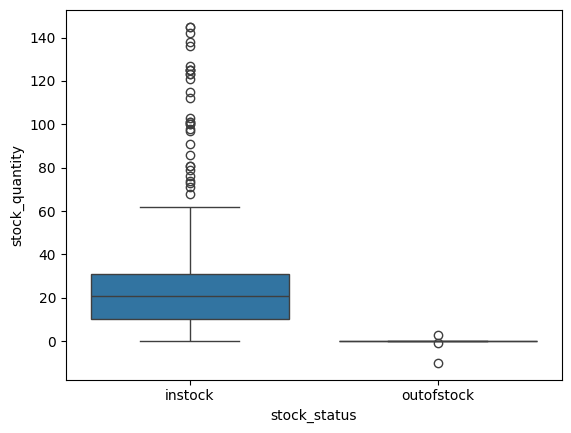

In [286]:
#Visualisation de la distribution des valeurs en fonction des catégories "instock" et "outstock"
sns.boxplot(x='stock_status', y='stock_quantity', data=df_erp)
plt.show()

In [287]:
#Création d'une colonne "stock_status_2"
#La valeur de cette deuxième colonne sera fonction de la valeur dans la colonne "stock_quantity"
#Si la valeur de la colonne "stock_quantity" est nulle, renseigner "outofstock" sinon mettre "instock"
df_erp['stock_status_2'] = df_erp['stock_quantity'].apply(lambda x: 'instock' if x > 0 else 'outofstock')
df_erp.head(5)

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
0,3847,1,24.2,16,instock,12.88,instock
1,3849,1,34.3,10,instock,17.54,instock
2,3850,1,20.8,0,outofstock,10.64,outofstock
3,4032,1,14.1,26,instock,6.92,instock
4,4039,1,46.0,3,outofstock,23.77,instock


In [288]:
#Vérifions que les 2 colonnes sont identiques:
#Les 2 colonnes sont strictement identiques si les valeurs de chaque ligne sont strictement identiques 2 à 2
#La comparaison de 2 colonnes peut se réaliser simplement avec l'instruction ci-dessous:
df_erp["stock_status"] == df_erp["stock_status_2"]

#Le résultat est l'affichage de True ou False pour chacune des lignes du dataset
#C'est un bon début, mais difficile à exploiter

,0
0,True
1,True
2,True
3,True
4,False
...,...
820,True
821,True
822,True
823,True


In [289]:
#Mais il est possible de synthétiser ce résultat en effectuant la somme de cette colonne:
#True vaut 1 et False 0
#Nous devrions obtenir la somme de 824 qui correspond au nombre de lignes dans ce dataset
(df_erp["stock_status"] == df_erp["stock_status_2"]).sum()

np.int64(823)

In [290]:
#Si les colonnes ne sont absolument pas identiques ligne à ligne alors identifier la ligne en écart
##Dans ce cas je vous donne ce lien pour apprendre à réaliser des filtres dans Pandas:
##https://bitbucket.org/hrojas/learn-pandas/src/master/
##Lesson 3
df_erp[df_erp['stock_status'] != df_erp['stock_status_2']]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
4,4039,1,46.0,3,outofstock,23.77,instock
398,4885,1,18.7,0,instock,9.66,outofstock


In [291]:
#Corriger la ou les données incohérentes (statuts erronés dans  'stock status')

df_erp['stock_status'] = df_erp['stock_quantity'].apply(lambda x: 'outofstock' if x <= 0 else 'instock')

#Vérification en utilisant le même code que plus haut pour afficher les problèmes
df_erp[df_erp['stock_status'] != df_erp['stock_status_2']]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1 - Analyse exploratoire de chaque variable du fichier erp.xlsx</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.1 - Analyse de la variable PRIX</h3>
</div>

In [292]:
###############
## LES PRIX  ##
###############

#Vérification des prix: Y a t-il des prix non renseignés, négatifs ou nuls?
#Afficher le ou les prix non renseignés dans la colonne "price"
print("Nombres d'articles avec un prix non renseigné: {}".format(df_erp['price'].isna().sum() )) #Saisir l'instruction manquante dans la fonction format

#Affiche le ou les prix négatifs ou nuls dans la colonne "price"
print("Nombre d'articles avec un prix négatif ou nuls: {}".format((df_erp['price'] <= 0).sum()))
print()
#Afficher le prix minimum de la colonne "price"
print("Le prix minimum est de {}".format(df_erp['price'].min()))
#Afficher le prix maximum de la colonne "price"
print("Le prix maximum est de {}".format(df_erp['price'].max()))
print()
#Afficher les prix inférieurs à 0 (qu'est-ce qu'il faut en faire ?)
print(df_erp[df_erp['price'] < 0])
#Suppression des valeurs négatives
df_erp = df_erp[df_erp['price'] >= 0]


Nombres d'articles avec un prix non renseigné: 0
Nombre d'articles avec un prix négatif ou nuls: 3

Le prix minimum est de -20.0
Le prix maximum est de 225.0

     product_id  onsale_web  price  stock_quantity stock_status  \
151        4233           0  -20.0               0   outofstock   
469        5017           0   -8.0               0   outofstock   
739        6594           0   -9.1              19      instock   

     purchase_price stock_status_2  
151           10.33     outofstock  
469            4.34     outofstock  
739            4.61        instock  


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.2 - Analyse de la variable STOCK</h3>
</div>

In [293]:
#######################
### stock_quantity  ###
#######################

#Vérification de la colonne stock quantity
print("Nombres d'articles dont la quantité est non renseigné ou négative : {}".format((df_erp['stock_quantity'].isna() | (df_erp['stock_quantity'] < 0)).sum()))

#Afficher la quantité minimum de la colonne "stock_quantity"
print("La quantité minimum est de {}".format(df_erp['stock_quantity'].min()))

#Afficher la quantité maximum de la colonne "stock_quantity"
print("La quantité maximum est de {}".format(df_erp['stock_quantity'].max()))
print()
#Afficher les stocks inférieurs à 0 (qu'est-ce qu'il faut en faire ?)
print(df_erp[df_erp['stock_quantity'] < 0])
# Le statut associé est 'outofstock' ce qui signifie que la valeur devrait être "0", mais le statut du stock est peut-être dépendant de la quantité saisie, donc cela peut-être erronée
#Je supprime ces données marginales par rapport à la taille de notre échantillon
df_erp = df_erp[df_erp['stock_quantity'] >= 0]

Nombres d'articles dont la quantité est non renseigné ou négative : 2
La quantité minimum est de -10
La quantité maximum est de 145

     product_id  onsale_web  price  stock_quantity stock_status  \
449        4973           0   10.0             -10   outofstock   
573        5700           1   44.5              -1   outofstock   

     purchase_price stock_status_2  
449            4.96     outofstock  
573           22.30     outofstock  


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.3 - Analyse de la variable ONSALE_WEB</h3>
</div>

In [294]:
#Vérification de la colonne onsale_web et des valeurs qu'elle contient. Que signifient-elles?
print("Nombres de lignes sans aucune valeur : {}".format(df_erp['onsale_web'].isna().sum()))
#Cette colonne indique si le produit est en vente en ligne, 0 pour non, 1 pour oui

Nombres de lignes sans aucune valeur : 0


In [295]:
#Quelles sont les colonnes à conserver selon vous?
df_erp.head(5)
#Toutes les colonnes ont du sens en dehors de "stock status_2" qui a été rajouté et qui fait doublon désormais après la correction des erreurs

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
0,3847,1,24.2,16,instock,12.88,instock
1,3849,1,34.3,10,instock,17.54,instock
2,3850,1,20.8,0,outofstock,10.64,outofstock
3,4032,1,14.1,26,instock,6.92,instock
4,4039,1,46.0,3,instock,23.77,instock


In [296]:
#Supprimer la colonne comportant le libellé "stock_status_2" car elle est redondante
#avec la colonne "stock_status".
del df_erp['stock_status_2']
df_erp.head(5)

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,instock,23.77


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.4 - Analyse de la variable prix d'achat</h3>
</div>

In [297]:
######################
##   prix d'achat   ##
######################

#Vérification de la colonne purchase_price :
#Afficher le ou les prix non renseignés dans la colonne "purchase_price"
print("Nombres de prix d'achat non renseigné ou négatif : {}".format((df_erp['purchase_price'].isna() | (df_erp['purchase_price'] < 0)).sum()))

#Afficher le prix minimum de la colonne "purchase_price"
print("Le prix d'achat minimum est de {}".format(df_erp['purchase_price'].min()))

#Afficher le prix maximum de la colonne "purchase_price"
print("Le prix d'achat maximum est de {}".format(df_erp['purchase_price'].max()))


Nombres de prix d'achat non renseigné ou négatif : 0
Le prix d'achat minimum est de 2.74
Le prix d'achat maximum est de 137.81


In [298]:
#nombre de lignes du df_erp
print("Le tableau comporte {} observation(s) ou article(s)".format(df_erp.shape[0]))

Le tableau comporte 820 observation(s) ou article(s)


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.2 - Analyse exploratoire du fichier web.xlsx</h3>
</div>


In [299]:
#Dimension du dataset
#Nombre d'observations
print("Le tableau comporte {} observations ".format(df_web.shape[0]))
#Nombre de caractéristiques
df_web.info()

Le tableau comporte 1513 observations 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1513 entries, 0 to 1512
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   sku                    1428 non-null   object        
 1   virtual                1513 non-null   int64         
 2   downloadable           1513 non-null   int64         
 3   rating_count           1513 non-null   int64         
 4   average_rating         1430 non-null   float64       
 5   total_sales            1430 non-null   float64       
 6   tax_status             716 non-null    object        
 7   tax_class              0 non-null      float64       
 8   post_author            1430 non-null   float64       
 9   post_date              1430 non-null   datetime64[ns]
 10  post_date_gmt          1430 non-null   datetime64[ns]
 11  post_content           0 non-null      float64       
 12  product_type           

In [300]:
#Consulter le nombre de colonnes
print("Le tableau web comporte {} colonnes.".format(len(df_web.columns)))
#La nature des données dans chacune des colonnes
print("Les types de donneés dans chaque colonne sont :\n{}".format(df_web.dtypes))
#Le nombre de valeurs présentes dans chacune des colonnes
print("Pour chaque colonne, voici le nombre de valeurs :\n{}".format(df_web.count()))

Le tableau web comporte 29 colonnes.
Les types de donneés dans chaque colonne sont :
sku                              object
virtual                           int64
downloadable                      int64
rating_count                      int64
average_rating                  float64
total_sales                     float64
tax_status                       object
tax_class                       float64
post_author                     float64
post_date                datetime64[ns]
post_date_gmt            datetime64[ns]
post_content                    float64
product_type                     object
post_title                       object
post_excerpt                     object
post_status                      object
comment_status                   object
ping_status                      object
post_password                   float64
post_name                        object
post_modified            datetime64[ns]
post_modified_gmt        datetime64[ns]
post_content_filtered           flo

In [301]:
#Selon vous, quelles sont les colonnes à conserver ?
# Toutes les colonnes vides de valeurs, avec une valeur unique ou non requêtables (type commentaires), j'ai conservé 9 colonnes : sku, total_sales,, post_author,
# post_date_gmt, product_type, post_title, post_name, post_modified_gmt, post_type
df_web.head(5)

,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,tax_class,post_author,post_date,post_date_gmt,post_content,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_password,post_name,post_modified,post_modified_gmt,post_content_filtered,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
0,11862,0,0,0,0.0,3.0,NaN,NaN,2.0,2018-02-12 13:46:23,2018-02-12 12:46:23,NaN,Vin,Gilles Robin Hermitage Rouge 2012,NaN,publish,closed,closed,NaN,gilles-robin-hermitage-2012,2019-01-31 12:12:56,2019-01-31 11:12:56,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
1,16057,0,0,0,0.0,5.0,NaN,NaN,2.0,2018-04-17 15:29:17,2018-04-17 13:29:17,NaN,Vin,Domaine Pellé Sancerre Rouge La Croix Au Garde...,NaN,publish,closed,closed,NaN,pelle-sancerre-rouge-la-croix-au-garde-2017,2020-07-07 10:05:02,2020-07-07 08:05:02,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
2,14692,0,0,0,0.0,5.0,taxable,NaN,2.0,2019-03-19 10:06:47,2019-03-19 09:06:47,NaN,Vin,Château Fonréaud Bordeaux Blanc Le Cygne 2016,<div>Grâce à la complémentarité des 3 cépages ...,publish,closed,closed,NaN,fonreaud-bordeaux-blanc-le-cygne-2016,2020-04-25 21:40:31,2020-04-25 19:40:31,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
3,16295,0,0,0,0.0,14.0,NaN,NaN,2.0,2018-02-15 14:05:06,2018-02-15 13:05:06,NaN,Vin,Moulin de Gassac IGP Pays d'Hérault Guilhem Ro...,NaN,publish,closed,closed,NaN,moulin-de-gassac-igp-pays-dherault-guilhem-ros...,2020-08-27 18:55:03,2020-08-27 16:55:03,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
4,15328,0,0,0,0.0,2.0,taxable,NaN,2.0,2019-03-27 18:05:09,2019-03-27 17:05:09,NaN,Vin,Agnès Levet Côte Rôtie Maestria 2017,"<span style=""float: none; background-color: tr...",publish,closed,closed,NaN,agnes-levet-cote-rotie-maestria-2017,2020-07-25 15:45:02,2020-07-25 13:45:02,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0


In [302]:
#Si vous avez défini des colonnes à supprimer, effectuer l'opération
df_web = df_web.drop(columns=[
    'virtual', 'downloadable', 'rating_count', 'average_rating', 'tax_status', 'tax_class',
    'post_date', 'post_date_gmt', 'post_author', 'post_content', 'post_excerpt', 'post_status', 'comment_status', 'ping_status',
    'post_password', 'post_modified', 'post_content_filtered', 'post_parent', 'guid',
    'menu_order', 'post_mime_type', 'comment_count','post_name', 'post_modified_gmt','post_type'
])
df_web.head(5)

,sku,total_sales,product_type,post_title
0,11862,3.0,Vin,Gilles Robin Hermitage Rouge 2012
1,16057,5.0,Vin,Domaine Pellé Sancerre Rouge La Croix Au Garde...
2,14692,5.0,Vin,Château Fonréaud Bordeaux Blanc Le Cygne 2016
3,16295,14.0,Vin,Moulin de Gassac IGP Pays d'Hérault Guilhem Ro...
4,15328,2.0,Vin,Agnès Levet Côte Rôtie Maestria 2017


In [303]:
#Visualisation des valeurs de la colonne sku
print(df_web['sku'].unique())

[11862 16057 14692 16295 15328 15471 16515 16246 nan 13572 16513 16585
 16269 15526 12869 15575 11586 14338 15425 16560 15361 13809 11587 15022
 14323 16342 16029 15475 13754 14680 15875 9636 13849 13662 16564 13557
 15429 14712 15032 15481 15448 16580 15441 804 15300 13958 16071 15678
 13895 15711 12882 16053 13766 16247 12640 15292 15476 15670 16189 16038
 14864 16044 15324 15531 15953 15413 15733 14366 15895 15892 16472 15185
 16010 15793 15849 12315 15741 15934 15148 15781 15659 15106 15490 14507
 14149 16307 13736 14090 16037 15758 14661 12587 15337 15489 15201 16305
 16131 13435 15747 12203 14509 14768 16262 14561 16505 15717 16129 13460
 15871 15940 11602 13127 13520 15480 13032 15436 15269 15910 19821 16263
 15138 15146 15126 15482 16186 13905 16540 15856 15677 14700 15325 19815
 3506 16056 14975 15341 15204 15415 16065 15479 16151 15127 15140 15779
 15473 15530 14805 14106 9937 15281 16553 15315 15668 13211 15161 11258
 16296 12588 15792 15921 15690 15775 15577 15870 802 15163

In [304]:
df_web['sku'].nunique()

714

In [305]:
#Si vous avez identifié des codes articles ne respectant pas la régle de codification, consultez-les
df_web[df_web['sku'].apply(lambda x: not isinstance(x, (int, float)))]

,sku,total_sales,product_type,post_title
272,13127-1,4.0,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape 2007
842,bon-cadeau-25-euros,7.0,Autre,Bon cadeau de 25€
1117,13127-1,4.0,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape 2007
1387,bon-cadeau-25-euros,7.0,NaN,Bon cadeau de 25€


In [306]:
#Identifier les lignes sans code article
df_web[df_web['sku'].isna()]

,sku,total_sales,product_type,post_title
8,NaN,NaN,NaN,NaN
20,NaN,NaN,NaN,NaN
30,NaN,NaN,NaN,NaN
37,NaN,NaN,NaN,NaN
41,NaN,NaN,NaN,NaN
...,...,...,...,...
1384,NaN,NaN,NaN,NaN
1429,NaN,NaN,NaN,NaN
1432,NaN,NaN,NaN,NaN
1445,NaN,NaN,NaN,NaN


In [307]:
#Pour les codes articles identifiés, réaliser une analyse et définir l'action à entreprendre
##Je réimpute un nouvel identifiant aux deux lignes présentant une erreur dans la colonne sku
df_web.loc[df_web['sku'].astype(str).str.strip() == '13127-1', 'sku'] = 13128
##Je supprime les deux lignes avec pour valeur 'bon-cadeau-25-euros'
df_web = df_web[df_web['sku'] != 'bon-cadeau-25-euros']

In [308]:
#La clé pour chaque ligne est-elle unique? autrement dit, y a-t-il des doublons?
print("Il y a {} valeurs uniques".format(df_web['sku'].nunique()))
print("Il y a {} doublons".format(df_web['sku'].duplicated().sum()))

Il y a 713 valeurs uniques
Il y a 797 doublons


In [309]:
#Les lignes sans code article semblent être toutes non renseignées
#Pour s'en assurer, réaliser les étapes suivantes:
#1 - Créer un dataframe avec uniquement les lignes sans code article
df_web_vide = df_web[df_web['sku'].isna()]
#2 - Utiliser la fonction df.info() sur ce nouveau dataframe pour observer le nombre de valeurs renseignées dans chacune des colonnes
df_web_vide.info()
#3 - Que constatez-vous?
#Seules 2 lignes ont des données, mais avec un nombre de ventes négatives, ce qui indique une erreur. Sans Id impossible de faire un rapprochement

<class 'pandas.core.frame.DataFrame'>
Index: 85 entries, 8 to 1457
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sku           0 non-null      object 
 1   total_sales   2 non-null      float64
 2   product_type  2 non-null      object 
 3   post_title    2 non-null      object 
dtypes: float64(1), object(3)
memory usage: 3.3+ KB


In [310]:
## Suppression des lignes vides
df_web = df_web.dropna(subset=['sku'])
## Suppression des doublons
df_web = df_web.drop_duplicates(subset=['sku'], keep='first')
print("Pour chaque colonne, voici le nombre de valeurs :\n{}".format(df_web.count()))

Pour chaque colonne, voici le nombre de valeurs :
sku             713
total_sales     713
product_type    713
post_title      713
dtype: int64


In [311]:
##Suppression de la ligne avec l'id_web 14736 (car le product_id équivalent '5700' a été supprimé car avait un stock négatif)
df_web = df_web[df_web['sku'] != 14736]

In [312]:
#nombre de lignes du df_web
print("Le tableau comporte {} observation(s) ou article(s)".format(df_web.shape[0]))

Le tableau comporte 712 observation(s) ou article(s)


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.3 - Analyse exploratoire du fichier liaison.xlsx</h3>
</div>

In [313]:
#Dimension du dataset
#Nombre d'observations
print("Le tableau comporte {} observation(s) ou article(s)".format(df_liaison.shape[0]))
#Nombre de caractéristiques
df_liaison.info()

Le tableau comporte 825 observation(s) ou article(s)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_web      734 non-null    object
 1   product_id  825 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 13.0+ KB


In [314]:
#Consulter le nombre de colonnes
print("Le tableau comporte {} colonnes".format(df_liaison.shape[1]))

#La nature des données dans chacune des colonnes
print("Les types de donneés dans chaque colonne sont :\n{}".format(df_liaison.dtypes))
#Le nombre de valeurs présentes dans chacune des colonnes
print("Pour chaque colonne, voici le nombre de valeurs :\n{}".format(df_liaison.count()))

Le tableau comporte 2 colonnes
Les types de donneés dans chaque colonne sont :
id_web        object
product_id     int64
dtype: object
Pour chaque colonne, voici le nombre de valeurs :
id_web        734
product_id    825
dtype: int64


In [315]:
#Les valeurs de la colonne "product_id" sont-elles toutes uniques?
df_liaison['product_id'].nunique()

825

In [316]:
#Les valeurs de la colonne "id_web" sont-elles toutes uniques?
df_liaison['id_web'].nunique()

734

In [317]:
#Avons-nous des articles sans correspondance?

print("Il y a {} articles sans correspondance dans la colonne id_web".format(df_liaison['id_web'].isna().sum()))
print("Il y a {} article(s) sans correspondance dans la colonne product_id".format(df_liaison['product_id'].isna().sum()))

Il y a 91 articles sans correspondance dans la colonne id_web
Il y a 0 article(s) sans correspondance dans la colonne product_id


In [318]:
## Nettoyage du fichier
## Correction de l'ID au mauvais format
df_liaison.loc[df_liaison['id_web'].astype(str).str.strip() == '13127-1', 'id_web'] = 13128

#Suppression d'ID erronés
df_liaison = df_liaison[df_liaison['id_web'] != 'bon-cadeau-25-euros']
df_liaison = df_liaison[df_liaison['id_web'] != '14680-1'] ## n'existe pas dans le df_web

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 3 - Jonction des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.1 - Jonction du fichier df_erp et df_liaison</h3>
</div>

In [319]:
#Fusion des fichiers df_erp et df_liaison
df_merge1 = pd.merge(df_liaison, df_erp, on="product_id", how="outer")
df_merge1.head(5)


,id_web,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,15298,3847,1.0,24.2,16.0,instock,12.88
1,15296,3849,1.0,34.3,10.0,instock,17.54
2,15300,3850,1.0,20.8,0.0,outofstock,10.64
3,19814,4032,1.0,14.1,26.0,instock,6.92
4,19815,4039,1.0,46.0,3.0,instock,23.77


In [320]:
#Y a t-il des lignes ne "matchant" pas entre les 2 fichiers?
print("Il y a {} articles sans correspondance dans la colonne id_web".format(df_merge1['id_web'].isna().sum()))

Il y a 93 articles sans correspondance dans la colonne id_web


In [321]:
#nombre de lignes du dfmerge1
print("Le tableau comporte {} observation(s) ou article(s)".format(df_merge1.shape[0]))

Le tableau comporte 825 observation(s) ou article(s)


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.2 - Jonction du fichier df_merge et df_web</h3>
</div>

In [322]:
#Fusionner les datasets df_merge et df_web
#Je renomme d'abord la colone pour opérer la jointure
df_web=df_web.rename(columns={'sku': 'id_web'})

df_merge = pd.merge(df_web, df_merge1, on="id_web", how="outer")
df_merge.head(5)

,id_web,total_sales,product_type,post_title,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,38,10.0,Vin,Emile Boeckel Crémant Brut Blanc de Blancs,4729,1.0,8.6,26.0,instock,4.22
1,41,6.0,Vin,Marcel Windholtz Eau de Vie de Marc de Gewurzt...,4634,1.0,41.0,11.0,instock,20.12
2,304,8.0,Champagne,Champagne Gosset Grande Réserve,4141,1.0,39.0,123.0,instock,24.86
3,523,0.0,Cognac,Cognac Normandin Mercier VFC,5932,1.0,59.9,13.0,instock,27.18
4,531,8.0,Champagne,Champagne Petit Lebrun &amp; Fils Blanc de Bla...,5047,1.0,22.5,76.0,instock,13.78


In [323]:
#Avons-nous des lignes sans correspondance?
print("Il y a {} articles sans correspondance dans la colonne id_web".format(df_merge['product_id'].isna().sum()))

Il y a 0 articles sans correspondance dans la colonne id_web


In [324]:
#nombre de ligne du df df_merge
print("Le tableau comporte {} observation(s) ou article(s)".format(df_merge.shape[0]))

Le tableau comporte 825 observation(s) ou article(s)


In [325]:
#Contrôle de la dimension du df, le résultat est ici logique au regard de la fusion outter
df_merge.count()

,0
id_web,732
total_sales,712
product_type,712
post_title,712
product_id,825
onsale_web,820
price,820
stock_quantity,820
stock_status,820
purchase_price,820


**Etape 3 BONUS - Fusion des DF de manière restrictive**

In [326]:
## Merge inner des df erp et liaison
df_merge_strict_erp_liaison = pd.merge(df_liaison, df_erp, on="product_id", how="inner")
df_merge_strict_erp_liaison.head(5)

,id_web,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,15298,3847,1,24.2,16,instock,12.88
1,15296,3849,1,34.3,10,instock,17.54
2,15300,3850,1,20.8,0,outofstock,10.64
3,19814,4032,1,14.1,26,instock,6.92
4,19815,4039,1,46.0,3,instock,23.77


In [327]:
#nombre de lignes du df
print("Le tableau comporte {} observation(s) ou article(s)".format(df_merge_strict_erp_liaison.shape[0]))

Le tableau comporte 818 observation(s) ou article(s)


In [328]:
#"On pourrait s'attendre à avoir 820 lignes mais deux lignes n'apparaissent pas. Il s'agit de l'ID du bon-cadeau-25-euros, supprimés dans le df_liaison
##et d'un id_web au mauvais format inscrit dans df_laison et n'existant pas dans df_web
set(df_erp['product_id']) - set(df_liaison['product_id'])

{4954, 7329}

In [329]:
## Merge des datasets df_merge_stric_erp_liaison et df_web
df_merge_strict = pd.merge(df_web, df_merge_strict_erp_liaison, on="id_web", how="inner")
df_merge_strict.head(5)

,id_web,total_sales,product_type,post_title,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,11862,3.0,Vin,Gilles Robin Hermitage Rouge 2012,4069,1,60.0,4,instock,30.07
1,16057,5.0,Vin,Domaine Pellé Sancerre Rouge La Croix Au Garde...,4673,1,19.8,17,instock,10.33
2,14692,5.0,Vin,Château Fonréaud Bordeaux Blanc Le Cygne 2016,5794,1,21.7,15,instock,10.65
3,16295,14.0,Vin,Moulin de Gassac IGP Pays d'Hérault Guilhem Ro...,4200,0,5.8,33,instock,3.12
4,15328,2.0,Vin,Agnès Levet Côte Rôtie Maestria 2017,5827,1,55.0,4,instock,29.55


In [330]:
#nombre de ligne du df_merge
print("Le tableau comporte {} observation(s) ou article(s)".format(df_merge_strict.shape[0]))

Le tableau comporte 712 observation(s) ou article(s)


In [331]:
# #Contrôle de la dimension du df
df_merge_strict.count()

,0
id_web,712
total_sales,712
product_type,712
post_title,712
product_id,712
onsale_web,712
price,712
stock_quantity,712
stock_status,712
purchase_price,712


A partir de cette étape, je vais utiliser parallèlement les deux df créés : df_merge et df_merge strict en fonction des calculs demandés et en fonction de leur pertinence



<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 4 - Analyse univariée des prix</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.1 - Exploration par la visualisation de données</h3>
</div>

Text(0, 0.5, 'Prix (€)')

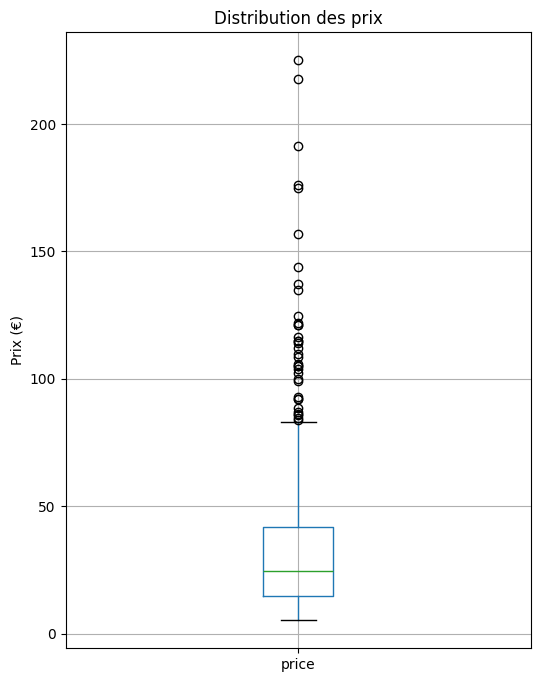

In [332]:
#Création d'une boîte à moustache de la répartition des prix grâce à Pandas
ax = df_merge.boxplot(column="price", figsize=(6,8))
ax.set_title("Distribution des prix")
ax.set_ylabel("Prix (€)")

In [333]:
#Autre méthode avec plotly express
px.box(df_merge, y="price",  points="all")

In [334]:
## Pas de différences notables entre les df_merge et df_merge_strict

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2 - Exploration par l'utilisation de méthodes statistiques</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.1 - Identification par le Z-index</h3>
</div>

In [335]:
#Calculer la moyenne du prix
moyenne_prix = df_merge['price'].mean()
print("La moyenne des prix est de {} €.".format(round(moyenne_prix,1)))
#Calculer l'écart-type du prix
ecart_type = df_merge['price'].std()
print(f"L'écart-type est de {ecart_type:.1f}.")
#Calculer le Z-score
df_merge['z_score'] = (df_merge['price'] - moyenne_prix) / ecart_type
df_merge.head(5)

La moyenne des prix est de 32.4 €.
L'écart-type est de 26.6.


,id_web,total_sales,product_type,post_title,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,z_score
0,38,10.0,Vin,Emile Boeckel Crémant Brut Blanc de Blancs,4729,1.0,8.6,26.0,instock,4.22,-0.891991
1,41,6.0,Vin,Marcel Windholtz Eau de Vie de Marc de Gewurzt...,4634,1.0,41.0,11.0,instock,20.12,0.324220
2,304,8.0,Champagne,Champagne Gosset Grande Réserve,4141,1.0,39.0,123.0,instock,24.86,0.249145
3,523,0.0,Cognac,Cognac Normandin Mercier VFC,5932,1.0,59.9,13.0,instock,27.18,1.033677
4,531,8.0,Champagne,Champagne Petit Lebrun &amp; Fils Blanc de Bla...,5047,1.0,22.5,76.0,instock,13.78,-0.370222


In [336]:
## Calcul du nombre de valeurs dont le z_score est supérieur à 3
nb_sup_3 = (df_merge['z_score'] > 3).sum()
print(f"Nombre de prix avec z_score > 3 : {nb_sup_3}")
##Calcul de leur proportion dans l'ensemble du df
proportion_outliers_zscore = (nb_sup_3 / len(df_merge)) * 100
print(f"Proportion d'outliers : {proportion_outliers_zscore:.1f}%")

Nombre de prix avec z_score > 3 : 17
Proportion d'outliers : 2.1%


In [337]:
#Quel est le seuil prix dont le z-score est supérieur à 3?
df_merge[df_merge['z_score'] > 3]
seuil_prix = df_merge.loc[df_merge['z_score'] > 3, 'price'].min()
print(f"Le seuil de prix à partir duquel le z-score > 3 est {seuil_prix} €.")

Le seuil de prix à partir duquel le z-score > 3 est 114.0 €.


**DF Strict**

---



In [338]:
#Calculer la moyenne du prix
moyenne_prix_strict = df_merge_strict['price'].mean()
print("La moyenne des prix est de {} €.".format(round(moyenne_prix_strict,1)))
#Calculer l'écart-type du prix
ecart_type_strict = df_merge_strict['price'].std()
print(f"L'écart-type est de {ecart_type_strict:.1f}.")
#Calculer le Z-score
df_merge_strict['z_score'] = (df_merge_strict['price'] - moyenne_prix_strict) / ecart_type_strict


La moyenne des prix est de 32.3 €.
L'écart-type est de 27.6.


In [339]:
## Calcul du nombre de valeurs dont le z_score est supérieur à 3
nb_sup_3_strict = (df_merge_strict['z_score'] > 3).sum()
print(f"Nombre de prix avec z_score > 3 : {nb_sup_3_strict}")
##Calcul de leur proportion dans l'ensemble du df
proportion_outliers_zscore_strict = (nb_sup_3_strict / len(df_merge_strict)) * 100
print(f"Proportion d'outliers : {proportion_outliers_zscore_strict:.1f}%")

Nombre de prix avec z_score > 3 : 13
Proportion d'outliers : 1.8%


In [340]:
#Quel est le seuil prix dont le z-score est supérieur à 3?
df_merge_strict[df_merge_strict['z_score'] > 3]
seuil_prix_strict = df_merge_strict.loc[df_merge_strict['z_score'] > 3, 'price'].min()
print(f"Le seuil de prix à partir duquel le z-score > 3 est {seuil_prix_strict} €.")

Le seuil de prix à partir duquel le z-score > 3 est 116.4 €.


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.2 - Identification par l'intervalle interquartile</h3>
</div>

In [341]:
#Utilisation de la fonction "describe" de Pandas pour l'étude des mesures de dispersion
df_merge['price'].describe()

,price
count,820.000000
mean,32.362744
std,26.640110
min,5.200000
25%,14.600000
50%,24.400000
75%,42.000000
max,225.000000


In [342]:
#Définir un seuil pour les articles "outliers" en prix
stats = df_merge['price'].describe()
#Calcul de deux valeurs interquartiles
Q1 = stats['25%']
Q3 = stats['75%']
#Uilisation de la méthode IQR
IQR = Q3 - Q1
borne_basse = Q1 - 1.5 * IQR
borne_haute = Q3 + 1.5 * IQR
outliers = df_merge[(df_merge['price'] < borne_basse) | (df_merge['price'] > borne_haute)]
print("🔹 Outliers détectés :")
print(outliers)

🔹 Outliers détectés :
    id_web  total_sales product_type  \
22    3507          4.0       Cognac   
23    3509          5.0       Cognac   
24    3510          3.0       Cognac   
33    7819          4.0       Cognac   
53   11601          6.0          Vin   
54   11602          7.0          Vin   
56   11668          5.0          Vin   
87   12790          4.0          Vin   
88   12791          3.0          Vin   
89   12857          1.0          Vin   
144  13853          7.0    Champagne   
150  13913          9.0    Champagne   
151  13914          6.0    Champagne   
157  13982          2.0          Vin   
158  13996          7.0          Vin   
172  14220          3.0          Vin   
205  14581          2.0          Vin   
206  14596          6.0          Vin   
234  14773          3.0       Whisky   
235  14774          1.0       Whisky   
236  14775          3.0       Whisky   
241  14805          2.0          Vin   
257  14915          1.0          Vin   
258  14923        

In [343]:
#Définir le nombre d'articles et la proportion de l'ensemble du catalogue "outliers"
nb_outliers_price = ((df_merge['price'] < borne_basse) |
                     (df_merge['price'] > borne_haute)).sum()
print("Le tableau comporte {} observation(s) ou article(s)".format(nb_outliers_price))
proportion_outliers = (nb_outliers_price / len(df_merge)) * 100

print(f"Proportion d'outliers : {proportion_outliers:.1f}%")

Le tableau comporte 36 observation(s) ou article(s)
Proportion d'outliers : 4.4%


In [344]:
#Selon vous, ces outliers sont-ils justifiés ? Comment le démontrer si cela est possible ?
# 2,1 % d'outliers selon la méthode zscore, 4,4 % selon la méthode IQR. Cela reste des proportions acceptables. Et concernant le produit, les données ne sont pas étonnantes,
# Il y a une grande variété de prix entre les différents produits, qui peuvent expliquer ces larges différences.

**DF Strict**

In [345]:
#Utilisation de la fonction "describe" de Pandas pour l'étude des mesures de dispersion
df_merge_strict['price'].describe()

,price
count,712.000000
mean,32.326896
std,27.629982
min,5.200000
25%,14.037500
50%,23.400000
75%,42.025000
max,225.000000


In [346]:
#Définir un seuil pour les articles "outliers" en prix
stats_strict = df_merge_strict['price'].describe()
#Calcul de deux valeurs interquartiles
Q1_strict = stats['25%']
Q3_strict = stats['75%']
#Uilisation de la méthode IQR
IQR_strict = Q3_strict - Q1_strict
borne_basse_strict = Q1_strict - 1.5 * IQR_strict
borne_haute_strict = Q3_strict + 1.5 * IQR_strict
outliers_strict = df_merge_strict[(df_merge_strict['price'] < borne_basse_strict) | (df_merge_strict['price'] > borne_haute_strict)]


In [347]:
#Définir le nombre d'articles et la proportion de l'ensemble du catalogue "outliers"
nb_outliers_price_strict = ((df_merge_strict['price'] < borne_basse_strict) |
                     (df_merge_strict['price'] > borne_haute_strict)).sum()
print("Le tableau comporte {} observation(s) ou article(s)".format(nb_outliers_price_strict))
proportion_outliers_strict = (nb_outliers_price_strict / len(df_merge_strict)) * 100

print(f"Proportion d'outliers : {proportion_outliers_strict:.1f}%")

Le tableau comporte 32 observation(s) ou article(s)
Proportion d'outliers : 4.5%


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 5 - Analyse univariée du CA, des quantités vendues, des stocks et de la marge ainsi qu'une analyse multivariée  </h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.1 - Analyse des ventes en CA</h3>
</div>

In [348]:
##############################
# Calculer le CA du site web #
##############################

#Le df_merge strict est le df qui correspond aux aux articles vendus sur le web
#Créer une colonne calculant le CA par article
#Calcul du CA par article
df_merge_strict['CA par article'] = round(df_merge_strict['total_sales']*df_merge_strict['price'],1)

#Calculer la somme de la colonne "ca_par_article"
CA_total_web = df_merge_strict['CA par article'].sum()

print("Le chiffre d'affaire du site web est de {} €.".format(round(CA_total_web,1)))
#Ce résultat correspond au chiffre d'affaire du site web

Le chiffre d'affaire du site web est de 153217.2 €.


In [349]:
###############################
# Palmarès des articles en CA #
###############################

#Effectuer le tri dans l'ordre décroissant du CA du dataset df_merge
df_merge_strict.sort_values(by='CA par article', ascending=False, inplace=True)
#Réinitialiser l'index du dataset par un reset_index
df_merge_strict = df_merge_strict.reset_index(drop=True)
#Afficher les 20 premiers articles en CA
df_merge_strict.head(20)
#Graphique en barre des 20 premiers articles avec plotly express
  # Top 20 tri décroissant
top20_articlesCA = df_merge_strict.sort_values(by='CA par article', ascending=False).head(20)

fig1 = px.bar(
    top20_articlesCA,
    x='CA par article',
    y='post_title',
    orientation='h',
    title='Top 20 articles par chiffre d’affaire',
    text='CA par article'
)
# Lisibilité + tri correct
fig1.update_layout(
    yaxis=dict(categoryorder='total ascending'),
    bargap=0.3,
    template='plotly_white'
)

# Affichage du CA à l’extérieur
fig1.update_traces(
    texttemplate='%{x:,.0f} €',
    textposition='outside',
    outsidetextfont=dict(size=19)
)

fig1.show()

In [350]:
#############################
# Calculer le 20 / 80 en CA #
#############################

#Créer une colonne calculant la part du CA de la ligne dans le dataset
df_merge_strict['Part du CA total'] = df_merge_strict['CA par article']/df_merge_strict['CA par article'].sum()*100
# Classement par ordre décroissant
df_merge_strict = df_merge_strict.sort_values('CA par article', ascending=False)
#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
df_merge_strict['Part_cumulative_CA'] = df_merge_strict['Part du CA total'].cumsum()

#Grâce aux deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% du CA
df_merge_80_CA = df_merge_strict[df_merge_strict['Part_cumulative_CA'] <= 80]

#Afficher la proportion que représente ce groupe d'articles dans le catalogue entier du site web
print("La proportion du nombre d'articles représentant 80% du CA parmi le catalogue web est de {} %".format(round(df_merge_80_CA.shape[0]/df_merge_strict.shape[0]*100,1)))

La proportion du nombre d'articles représentant 80% du CA parmi le catalogue web est de 58.8 %


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.2 - Analyse des ventes en quantité</h3>
</div>

In [351]:
#####################################
# Palmarès des articles en quantité #
#####################################

#Effectuer le tri dans l'ordre décroissant de quantités vendues du dataset df_merge
df_merge_strict.sort_values(by='total_sales', ascending=False, inplace=True)
#Réinitialiser l'index du dataset par un reset_index
df_merge_strict = df_merge_strict.reset_index(drop=True)
#Afficher les 20 premiers articles en quantité
df_merge_strict.head(20)
#Graphique en barre des 20 premiers articles avec plotly express

top20_articles_quantité = df_merge_strict.sort_values(by='total_sales', ascending=False).head(20)

fig2 = px.bar(
    top20_articles_quantité,
    x='total_sales',
    y='post_title',
    orientation='h',
    title='Top 20 articles en quantité',
    text='total_sales'
)
# Lisibilité + tri correct
fig2.update_layout(
    yaxis=dict(categoryorder='total ascending'),
    bargap=0.3,
    template='plotly_white'
)

# Affichage du CA à l’extérieur
fig2.update_traces(
        textposition='outside'
)
fig2.show()

In [352]:
##################################
# Calculer le 20 / 80 en quantité#
##################################

#Créer une colonne calculant la part en quantité de la ligne dans le dataset
df_merge_strict['Part_des ventes_par_article'] = round(df_merge_strict['total_sales']/df_merge_strict['total_sales'].sum()*100,1)

# Classement par ordre décroissant
df_merge_strict = df_merge_strict.sort_values('total_sales', ascending=False)

#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
df_merge_strict['Part_cumulative_nb_ventes'] = df_merge_strict['Part_des ventes_par_article'].cumsum()

#Grâce aux deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% des ventes en quantité
df_merge_80_vente = df_merge_strict[df_merge_strict['Part_cumulative_nb_ventes'] <= 80]

#Afficher la proportion que représente ce groupe d'articles dans le catalogue entier du site web
print("La proportion du nombre d'articles représentant 80% du CA parmi le catalogue web est de {} %".format(round(df_merge_80_vente.shape[0]/df_merge_strict.shape[0]*100,1)))

La proportion du nombre d'articles représentant 80% du CA parmi le catalogue web est de 65.2 %


In [353]:
##Calcul du nombre total de ventes
total_sales = df_merge_strict['total_sales'].sum()
print("Le nombre total de ventes est de {} articles".format(total_sales))


Le nombre total de ventes est de 6066.0 articles


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.3 - Analyse des stocks</h3>
</div>

In [354]:
######################################
# Calculer le nombre de mois de stock #
######################################

#Import de numpy
import numpy as np

#Création de la colonne Rotation de stock
df_merge_strict['Rotation_de_stock'] = round(df_merge_strict["total_sales"] / df_merge_strict["stock_quantity"],1)
#Remplacement des "inf" par 0
df_merge_strict['Rotation_de_stock'] = df_merge_strict['Rotation_de_stock'].replace([np.inf, -np.inf], 0)
#Effectuer le tri dans l'ordre décroissant du nombre de mois de stock dans le dataset df_merge
df_merge_strict.sort_values(by='Rotation_de_stock', ascending=False, inplace=True)

#Graphique en barre du flop 20 des produits qui ont le plus de mois de stock

fig3_strict = px.bar(
    df_merge_strict.sort_values(by='Rotation_de_stock', ascending=False).head(20),
    x='Rotation_de_stock',
    y='post_title',
    title='Top 20 articles par rotation de stock',
    text='Rotation_de_stock',
    orientation='h'   # barres horizontales
)
fig3_strict.update_layout(yaxis={'autorange':'reversed'})
fig3_strict.update_traces(textposition='outside')
fig3_strict.show()

In [355]:
#Calcul de la rotation de stocks moyenne
print("La rotation de stock moyenne est de {} mois".format(round(df_merge_strict['Rotation_de_stock'].mean(),1)))

La rotation de stock moyenne est de 0.5 mois


In [356]:
####################################
# Valorisation des stocks en euros #
####################################

#Création de la colonne Valorisation des stocks en euros
df_merge_strict['Valorisation_stock_euros'] = round(df_merge_strict['stock_quantity']*df_merge_strict['purchase_price'],1)
#Calculer la somme de la colonne "Valorisation_stock_euros"
CA_total_stock_strict = df_merge_strict['Valorisation_stock_euros'].sum()
print("La valeur de stock du site web est de {} €.".format(round(CA_total_stock_strict,1)))

La valeur de stock du site web est de 277022.2 €.


In [357]:
##############################################
# Valorisation du nombre de produits en stock #
##############################################

#Calculer la somme de la colonne stock quantity
print("Le nombre total de produits en stock est {} articles".format(df_merge_strict['stock_quantity'].sum()))

Le nombre total de produits en stock est 16717 articles




```
Calcul pour le df merge
```



In [358]:
#Création de la colonne Rotation de stock
df_merge['Rotation_de_stock'] = round(df_merge["total_sales"] / df_merge["stock_quantity"] ,1)
#Remplacement des "inf" par 0
df_merge['Rotation_de_stock'] = df_merge['Rotation_de_stock'].replace([np.inf, -np.inf], 0)
#Effectuer le tri dans l'ordre décroissant du nombre de mois de stock dans le dataset df_merge
df_merge.sort_values(by='Rotation_de_stock', ascending=False, inplace=True)

#Graphique en barre du flop 20 des produits qui ont le plus de mois de stock

fig3 = px.bar(
    df_merge_strict.sort_values(by='Rotation_de_stock', ascending=False).head(20),
    x='Rotation_de_stock',
    y='post_title',
    title='Top 20 articles par rotation de stock',
    text='Rotation_de_stock',
    orientation='h'   # barres horizontales
)
fig3.update_layout(yaxis={'autorange':'reversed'})
fig3.update_traces(textposition='outside')
fig3.show()

In [359]:
#Calcul de la rotation de stocks moyenne
print("La rotation de stock moyenne est de {} mois".format(round(df_merge['Rotation_de_stock'].mean(),1)))

La rotation de stock moyenne est de 0.5 mois


In [360]:
####################################
# Valorisation des stocks en euros #
####################################

#Création de la colonne Valorisation des stocks en euros
df_merge['Valorisation_stock_euros'] = round(df_merge['stock_quantity']*df_merge['purchase_price'],1)
#Calculer la somme de la colonne "Valorisation_stock_euros"
CA_total_stock = df_merge['Valorisation_stock_euros'].sum()
print("La valeur de stock du site web est de {} €.".format(round(CA_total_stock,1)))

La valeur de stock du site web est de 298540.4 €.


In [361]:
##############################################
# Valorisation du nombre de produits en stock #
##############################################

#Calculer la somme de la colonne stock quantity
print("Le nombre total de produits en stock est {} articles".format(df_merge['stock_quantity'].sum()))

Le nombre total de produits en stock est 17803.0 articles


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.4 - Analyse du taux de marge</h3>
</div>

In [362]:
############################
# Analyse du taux de marge #
############################

#Création de la colonne Prix HT
df_merge_strict['Prix_HT'] = round(df_merge_strict['price'] / 1.2, 1)
#Création de la colonne Taux de marge
df_merge_strict['Taux_marge'] = round((df_merge_strict['Prix_HT'] - df_merge_strict['purchase_price']) / df_merge_strict['Prix_HT'] * 100, 1)
#Afficher le prix minimum de la colonne "taux_marge"
print("Le taux de marge minimum est de {}".format(df_merge_strict['Taux_marge'].min()))
#Afficher le prix maximum de la colonne "taux_marge"
print("Le taux de marge maximum est de {}".format(df_merge_strict['Taux_marge'].max()))
#Il y a une valeur inattendue sur sur le taux de marge minimum, elle est liée au purchase price(77,48) largement supérieur au price(12,65), ce qui est illogique - à traiter

Le taux de marge minimum est de -637.9
Le taux de marge maximum est de 47.8


In [363]:
#Affichage de la ligne avec un taux de marge inférieur à 0
df_merge_strict[df_merge_strict['Taux_marge'] < 0]

,id_web,total_sales,product_type,post_title,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,z_score,CA par article,Part du CA total,Part_cumulative_CA,Part_des ventes_par_article,Part_cumulative_nb_ventes,Rotation_de_stock,Valorisation_stock_euros,Prix_HT,Taux_marge
708,12589,0.0,Champagne,Champagne Egly-Ouriet Grand Cru Blanc de Noirs,4355,1,12.65,97,instock,77.48,-0.712157,0.0,0.0,100.0,0.0,95.1,0.0,7515.6,10.5,-637.9


In [364]:
#Création d'un dataframe avec les taux positifs
df_merge_marge_pos = df_merge_strict[df_merge_strict['Taux_marge'] > 0]
#Afficher le prix minimum de la colonne "taux_marge"
print("Le taux de marge minimum est de {}%".format(df_merge_marge_pos['Taux_marge'].min()))

#Afficher le prix maximum de la colonne "taux_marge"
print("Le taux de marge maximum est de {}%".format(df_merge_marge_pos['Taux_marge'].max()))


Le taux de marge minimum est de 22.7%
Le taux de marge maximum est de 47.8%


In [365]:
#Création d'un dataframe avec le taux de marge moyen par type de produit
df_marge_moyen = (
    df_merge_marge_pos
        .groupby('product_type', as_index=False)['Taux_marge']
        .mean()
        .round(1)
        .sort_values('Taux_marge', ascending=False)
)
#Affichage dans un graphique du taux de marge par type de produit
fig4 = px.bar(
    df_marge_moyen.head(20),
    x='product_type',          # <- colonne existante
    y='Taux_marge',
    title='Taux de marge moyen par type de produit',
    text='Taux_marge'
)
fig4.update_layout(xaxis_tickangle=-45)
fig4.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.5 - Analyse des corrélations entre les variables stock, sales et price</h3>
</div>

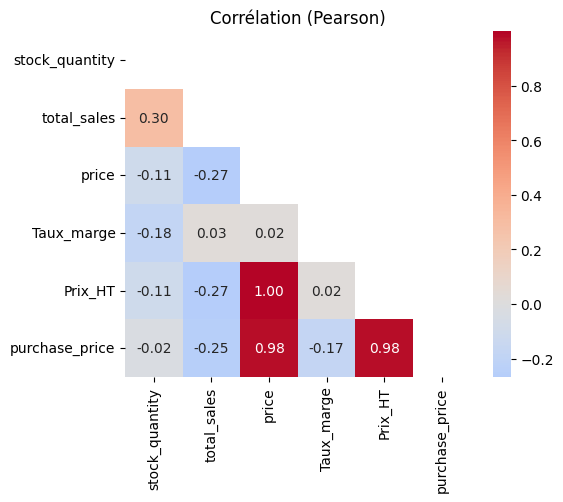

In [366]:
############################
# Analyse des corrélations #
############################

#Création d'une heatmap de corrélation avec les variables stock, sales et price

cols = ['stock_quantity', 'total_sales', 'price', 'Taux_marge', 'Prix_HT', 'purchase_price' ]
num = df_merge_strict[cols].apply(pd.to_numeric, errors='coerce')

corr = num.corr(method='pearson')

# Recalcule un mask adapté à la taille actuelle
mask = np.triu(np.ones(corr.shape, dtype=bool))  # masque la moitié supérieure (diagonale incluse)

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, fmt=".2f", mask=mask, center=0, cmap='coolwarm', square=True)
plt.title("Corrélation (Pearson)")
plt.tight_layout()
plt.show()

In [367]:
#Que peut-on conclure des corrélations ?
#Les variables de prix sont corrélées (price, prixHT et purchase price) ce qui est logique. Il y a une corrélation négative, mais faible,  entre les ventes et le prix.
#Les articles les plus onéreux ne sont pas ceux tirent vers le haut le CA.
#Corrélation entre stock et vente : les produits les plus sotckés sont les plus vendus
#Pas de corrélation majeure entre la marge et les autres dimensions

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.6 - Mise à disposition de la nouvelle table sur un fichier Excel</h3>
</div>

In [368]:
# Sauvegarde en Excel
df_merge.to_excel("df_merge.xlsx", index=False)
df_merge_strict.to_excel("df_merge_strict.xlsx", index=False)
# Téléchargement direct dans ton navigateur
from google.colab import files
files.download("df_merge.xlsx")
files.download("df_merge_strict.xlsx")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>